In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

In [2]:
data = np.load("raw_eye_data.npz")
X = data["X"]
y = data["y"]

In [3]:
N, C, T = X.shape

rms = np.zeros((N, C))
peak = np.zeros((N, C))
spike = np.zeros(N)
corr_mean = np.zeros(N)

for i in range(N):
    w = X[i]

    rms[i] = np.sqrt(np.mean(w**2, axis=1))
    peak[i] = np.max(np.abs(w), axis=1)

    diff = np.diff(w, axis=1)
    spike[i] = np.max(np.abs(diff))

    corr = np.corrcoef(w)
    upper = corr[np.triu_indices_from(corr, k=1)]
    corr_mean[i] = np.mean(np.abs(upper))

In [4]:
rms_mu, rms_std = rms.mean(), rms.std()
peak_mu, peak_std = peak.mean(), peak.std()
spike_mu, spike_std = spike.mean(), spike.std()

bad_rms   = np.any(rms > rms_mu + 6 * rms_std, axis=1)
bad_peak  = np.any(peak > peak_mu + 10 * peak_std, axis=1)
bad_spike = spike > spike_mu + 10 * spike_std
bad_corr  = corr_mean > 0.95

In [5]:
bad = bad_rms | bad_peak | bad_spike | bad_corr
good = ~bad

X_clean = X[good]
y_clean = y[good]

print("Original windows:", len(X))
print("Kept windows:", len(X_clean))
print("Dropped:", bad.sum())

X_clean = np.clip(X_clean, -100, 100)  # µV

np.savez(
    "clean_eye_data.npz",
    X=X_clean,
    y=y_clean
)

Original windows: 15
Kept windows: 15
Dropped: 0


Open windows: 6
Closed windows: 9


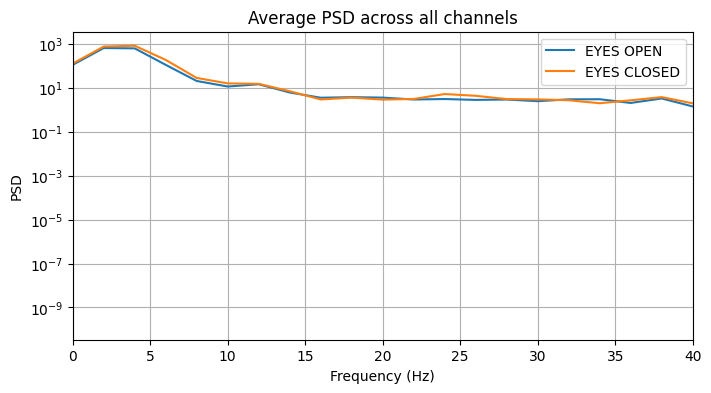

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

fs = 250  # sampling rate

def avg_psd(X, fs):
    if len(X) == 0:
        raise ValueError("No windows in this class")

    psds = []
    f = None

    for w in X:                      # windows
        ch_psd = []
        for ch in range(w.shape[0]): # channels
            f, Pxx = welch(w[ch], fs=fs, nperseg=fs//2)
            ch_psd.append(Pxx)
        psds.append(np.mean(ch_psd, axis=0))  # avg channels

    return np.mean(psds, axis=0), f           # avg windows

# split by state
X_open = X[y == 0]
X_closed = X[y == 1]

print("Open windows:", len(X_open))
print("Closed windows:", len(X_closed))

psd_open, freqs = avg_psd(X_open, fs)
psd_closed, _ = avg_psd(X_closed, fs)

# plot
plt.figure(figsize=(8, 4))
plt.semilogy(freqs, psd_open, label="EYES OPEN")
plt.semilogy(freqs, psd_closed, label="EYES CLOSED")
plt.xlim(0, 40)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")
plt.title("Average PSD across all channels")
plt.legend()
plt.grid(True)
plt.show()

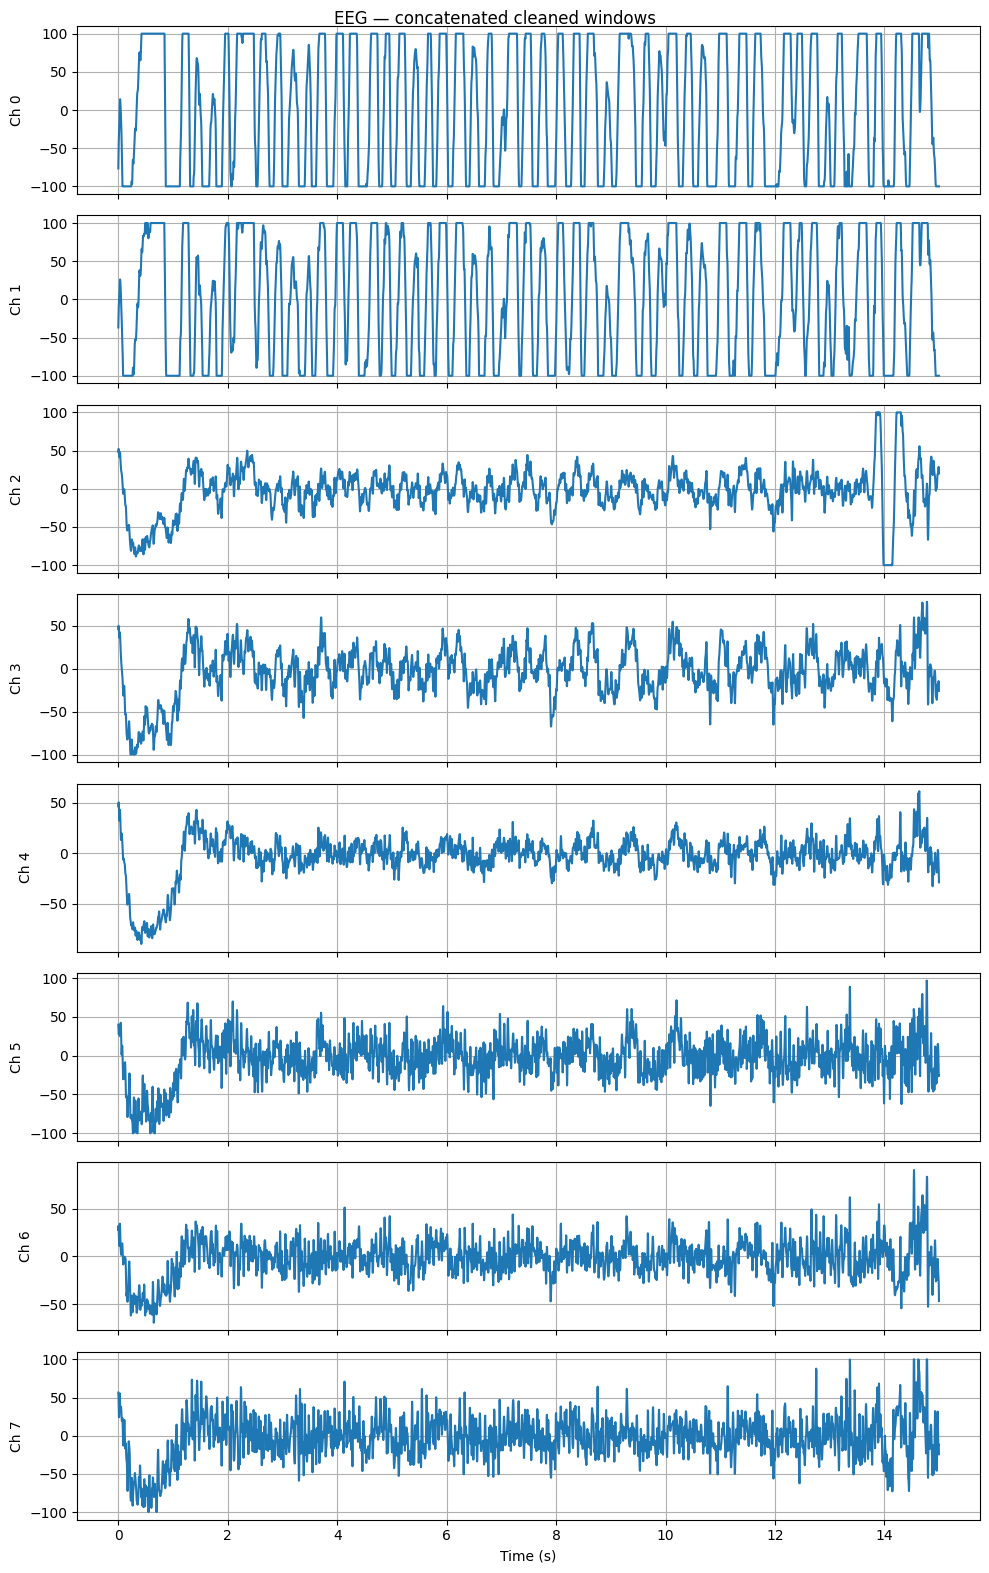

In [8]:
# concatenate windows along time
X_long = X_clean.transpose(1, 0, 2).reshape(C, -1)  # (C, N*T)
t_long = np.arange(X_long.shape[1]) / fs

fig, axes = plt.subplots(C, 1, figsize=(10, 2*C), sharex=True)

for ch in range(C):
    axes[ch].plot(t_long, X_long[ch])
    axes[ch].set_ylabel(f"Ch {ch}")
    axes[ch].grid(True)

axes[-1].set_xlabel("Time (s)")
fig.suptitle("EEG — concatenated cleaned windows")
plt.tight_layout()
plt.show()